# 3.基础架构

In [29]:
import torch.nn as nn
import torch
device=torch.device('cpu')
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        """
        初始化多层感知机
        input_size: 输入特征维度
        hidden_size: 隐藏状态维度  
        output_size: 输出维度
        """
        super().__init__()
        self.l1=nn.Linear(input_size,hidden_size)
        self.l2=nn.Linear(hidden_size,output_size)
        
    def relu(self, x):
        """激活函数实现
           这里只给出了relu
        """
        return torch.max(torch.tensor(0),x)
    def forward(self, x):
        """前向传播实现"""
        x=self.l1(x)
        x=self.relu(x)
        x=self.l2(x)
        return x

# 4.简单的MLP实验

## 生成数据

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def generate_circles(n_samples=1000, noise=0.05):
    """随机生成圆形数据集"""
    n_samples=1000;noise=0.05
    # 内圆（标签0，半径<0.4）、外圆（标签1，半径>0.6）
    n = n_samples//2
    # 内圆：极坐标转直角坐标
    inner_r = np.random.uniform(0, 0.4,size=(n,1))
    inner_ang = np.random.uniform(0, 2*np.pi, (n,1))
    inner = np.c_[ inner_r*np.cos(inner_ang), inner_r*np.sin(inner_ang)] 
    
    # 外圆
    outer_r = np.random.uniform(0.6, 1.0, (n,1))
    outer_ang = np.random.uniform(0, 2*np.pi, (n,1))
    outer = np.c_[outer_r*np.cos(outer_ang), outer_r*np.sin(outer_ang)]
    
    # 加噪声、合并、打乱
    X = np.r_[inner, outer] + np.random.normal(0, noise, (n_samples, 2))
    y = np.r_[np.zeros(n), np.ones(n)]
    idx = np.random.permutation(n_samples)
    return X[idx],y[idx]
input,label=generate_circles()
input=torch.from_numpy(input).float().to(device)
label=torch.from_numpy(label).long().to(device)

## 训练

In [31]:
model=MLP(2,16,2).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

for i in range (9000):
    optimizer.zero_grad()
    output=model(input)
    loss=criterion(output,label)
    loss.backward()
    optimizer.step()

## 统计参数的分布情况（画出频率分布图）

In [32]:
sxp=list(model.parameters())[0].detach().numpy().reshape(-1,1)
for k in list(model.parameters())[1:]:
    sxp=np.r_[k.detach().numpy().reshape(-1,1) ,sxp]

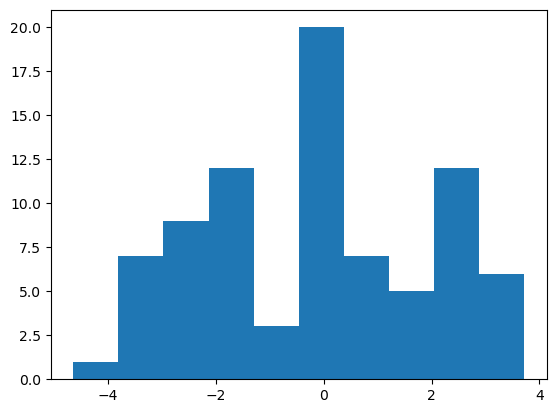

In [33]:
import matplotlib.pyplot as plt

plt.hist(sxp.flatten())
plt.show()